In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [52]:
df=pd.read_csv('Cleaned_Salary.csv')

In [53]:
df.columns

Index(['title', 'company', 'location', 'salary', 'rating', 'hourly', 'min_sal',
       'max_sal', 'avg_salary', 'city', 'state'],
      dtype='object')

In [54]:
df.shape


(605, 11)

In [55]:
df['title']

0                                    Risk Data Scientist
1                               Associate Data Scientist
2                                         Data Scientist
3                                   Data Scientist I, II
4                                         Data Scientist
5                                         DATA SCIENTIST
6                                       Data Scientist I
7                  Data Scientist-Toxicity Data Curation
8                                         Data Scientist
9                                      AI/Data Scientist
10                                        Data Scientist
11                                        Data Scientist
12                       Data Scientist I - Risk & Fraud
13                                        Data Scientist
14                                        Data Scientist
15                                        Data Scientist
16                          Data Scientist Engineer (US)
17                             

In [56]:
def title_simplifier(title):
    if 'data scientist' in title.lower():
        return 'data scientist'
    elif 'data engineer' in title.lower():
        return 'data engineer'
    elif 'analyst' in title.lower():
        return 'analyst'
    elif 'machine learning' in title.lower():
        return 'mle'
    elif 'manager' in title.lower():
        return 'manager'
    elif 'director' in title.lower():
        return 'director'
    elif 'research' in title.lower():
        return 'research position'    
    else:
        return 'na'
def seniority(title):
    if 'sr' in title.lower() or 'senior' in title.lower() or 'sr' in title.lower() or 'lead' in title.lower() or 'principal' in title.lower():
        return 'senior'
    elif 'jr' in title.lower() or 'jr.' in title.lower():
        return 'jr'
    else:
        return 'na'      

In [57]:
df['job_simp']=df['title'].apply(title_simplifier)


In [58]:
df.job_simp.head()

0    data scientist
1    data scientist
2    data scientist
3    data scientist
4    data scientist
Name: job_simp, dtype: object

In [59]:
df.job_simp.value_counts()

job_simp
data scientist       552
na                    23
mle                   16
analyst                9
research position      3
data engineer          1
manager                1
Name: count, dtype: int64

In [60]:
df['job_seniority']=df.title.apply(seniority)

In [61]:
df['job_seniority'].value_counts()

job_seniority
na        453
senior    150
jr          2
Name: count, dtype: int64

In [62]:
df.state.value_counts()

state
 CA       137
Remote     96
 NY        42
 TX        39
 VA        33
 IL        24
 OH        22
 WA        20
 GA        20
 DC        19
 NJ        19
 CO        19
 MD        14
 PA        13
 MA        11
 UT         9
 FL         7
 AZ         7
 NC         6
 IN         5
 AR         4
 PR         4
 MO         4
 MN         4
 WI         3
 MI         3
 TN         3
 NV         2
 AL         2
 NM         2
 SC         2
 IA         1
 ME         1
 OR         1
 CT         1
 NE         1
 KY         1
 OK         1
 NH         1
 LA         1
 HI         1
Name: count, dtype: int64

In [63]:
df.columns


Index(['title', 'company', 'location', 'salary', 'rating', 'hourly', 'min_sal',
       'max_sal', 'avg_salary', 'city', 'state', 'job_simp', 'job_seniority'],
      dtype='object')

In [64]:
df.min_sal=df.apply(lambda x : x.min_sal * 2 if x.hourly==1 else x.min_sal, axis=1)
df.max_sal=df.apply(lambda x : x.max_sal * 2 if x.hourly==1 else x.max_sal, axis=1)

In [65]:
df.loc[df['hourly'] == 1, ['hourly', 'min_sal', 'max_sal','city','company']]

,hourly,min_sal,max_sal,city,company
5,1,160.00,180.00,Remote,GenuineXs LLC
73,1,50.00,80.00,United States,Continuum Resource Network
79,1,50.00,200.00,United States,Oland Technologies
84,1,170.00,180.00,Sunnyvale,Skyelia
88,1,110.22,124.00,Dallas,Pebal Bright Technologies LLC
131,1,100.08,130.00,Santa Clara,Hecta Data (DBA) Vilwaa
145,1,180.00,200.00,Deerfield Beach,CTI Consulting
157,1,100.00,100.00,Malvern,Intone Networks
158,1,33.66,151.26,Austin,Amazon.com Services LLC
169,1,70.00,80.00,Cambridge,Pfizer


In [66]:
temp=pd.read_csv('Cleaned_Salary.csv')

In [67]:
temp.loc[temp['hourly'] == 1, ['hourly', 'min_sal', 'max_sal','city','company']]

,hourly,min_sal,max_sal,city,company
5,1,80.00,90.00,Remote,GenuineXs LLC
73,1,25.00,40.00,United States,Continuum Resource Network
79,1,25.00,100.00,United States,Oland Technologies
84,1,85.00,90.00,Sunnyvale,Skyelia
88,1,55.11,62.00,Dallas,Pebal Bright Technologies LLC
131,1,50.04,65.00,Santa Clara,Hecta Data (DBA) Vilwaa
145,1,90.00,100.00,Deerfield Beach,CTI Consulting
157,1,50.00,50.00,Malvern,Intone Networks
158,1,16.83,75.63,Austin,Amazon.com Services LLC
169,1,35.00,40.00,Cambridge,Pfizer


In [68]:
temp.min_sal=temp.apply(lambda x : x.min_sal * 2 if x.hourly==1 else x.min_sal, axis=1)

In [69]:
temp.max_sal=temp.apply(lambda x : x.max_sal * 2 if x.hourly==1 else x.max_sal, axis=1)

In [70]:
df.min_sal=temp.min_sal

In [71]:
df.max_sal=temp.max_sal

In [72]:
df.describe

<bound method NDFrame.describe of                                                  title  \
0                                  Risk Data Scientist   
1                             Associate Data Scientist   
2                                       Data Scientist   
3                                 Data Scientist I, II   
4                                       Data Scientist   
5                                       DATA SCIENTIST   
6                                     Data Scientist I   
7                Data Scientist-Toxicity Data Curation   
8                                       Data Scientist   
9                                    AI/Data Scientist   
10                                      Data Scientist   
11                                      Data Scientist   
12                     Data Scientist I - Risk & Fraud   
13                                      Data Scientist   
14                                      Data Scientist   
15                                    

In [73]:
df.title


0                                    Risk Data Scientist
1                               Associate Data Scientist
2                                         Data Scientist
3                                   Data Scientist I, II
4                                         Data Scientist
5                                         DATA SCIENTIST
6                                       Data Scientist I
7                  Data Scientist-Toxicity Data Curation
8                                         Data Scientist
9                                      AI/Data Scientist
10                                        Data Scientist
11                                        Data Scientist
12                       Data Scientist I - Risk & Fraud
13                                        Data Scientist
14                                        Data Scientist
15                                        Data Scientist
16                          Data Scientist Engineer (US)
17                             

In [74]:
df.describe()


,rating,hourly,min_sal,max_sal,avg_salary
count,605.000000,605.000000,605.000000,605.000000,605.000000
mean,3.391074,0.064463,106528.096298,158895.453025,132707.540223
std,1.421332,0.245779,46050.814871,80763.790823,60244.441904
min,-1.000000,0.000000,16.000000,28.000000,14.000000
25%,3.400000,0.000000,83000.000000,121000.000000,104000.000000
50%,3.700000,0.000000,104000.000000,151000.000000,130000.000000
75%,4.100000,0.000000,132000.000000,189000.000000,160000.000000
max,5.000000,1.000000,325000.000000,750000.000000,450000.000000


In [75]:
df.columns

Index(['title', 'company', 'location', 'salary', 'rating', 'hourly', 'min_sal',
       'max_sal', 'avg_salary', 'city', 'state', 'job_simp', 'job_seniority'],
      dtype='object')

<Axes: >

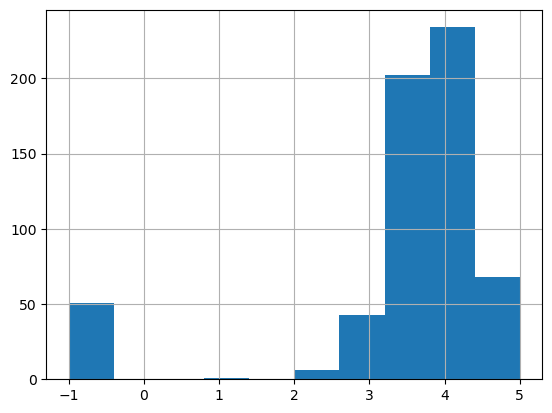

In [27]:
df.rating.hist()

<Axes: >

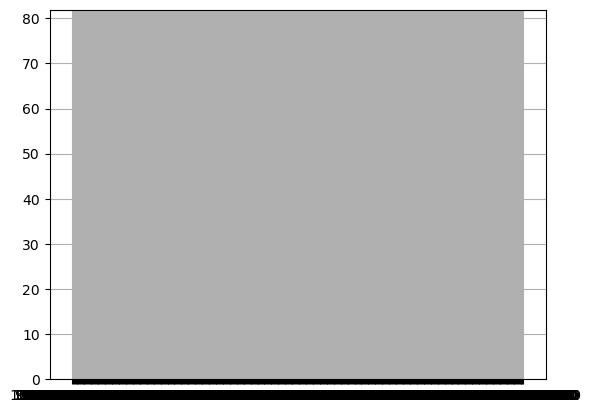

In [76]:
df.salary.hist()

<Axes: >

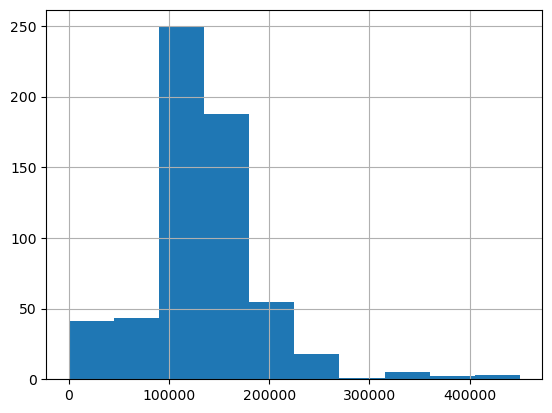

In [29]:
df.avg_salary.hist()

In [78]:
df.columns


Index(['title', 'company', 'location', 'salary', 'rating', 'hourly', 'min_sal',
       'max_sal', 'avg_salary', 'city', 'state', 'job_simp', 'job_seniority'],
      dtype='object')

<Axes: >

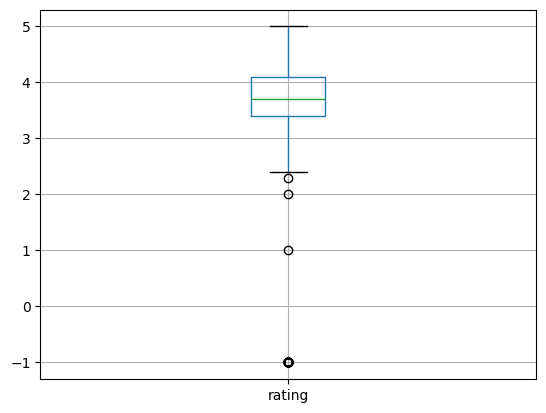

In [31]:
df.boxplot(column=['rating'])

<Axes: >

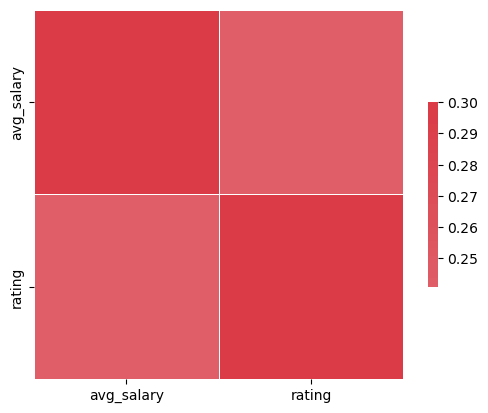

In [79]:
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(df[['avg_salary', 'rating']].corr(), vmax=.3, center=0, cmap=cmap, square=True, linewidths=.5, cbar_kws={'shrink': .5})

# Assistant
The error occurs because there's an unterminated string literal in your code. Specifically, there's a missing opening quote before 'avg_salary'.

Would you like me to provide the corrected code?

# User
yes

In [80]:
df.columns

Index(['title', 'company', 'location', 'salary', 'rating', 'hourly', 'min_sal',
       'max_sal', 'avg_salary', 'city', 'state', 'job_simp', 'job_seniority'],
      dtype='object')

In [81]:
df_cat=df[['min_sal','max_sal','avg_salary','rating']]

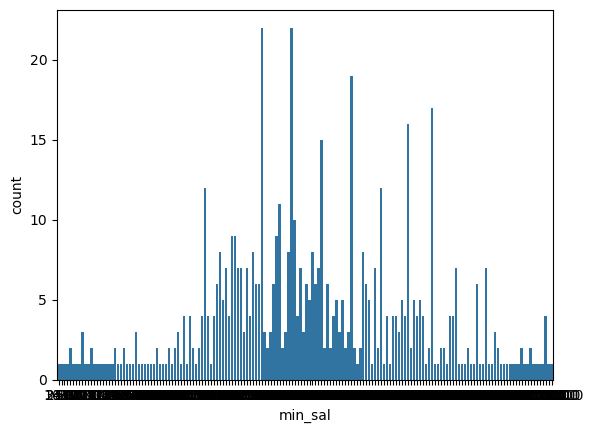

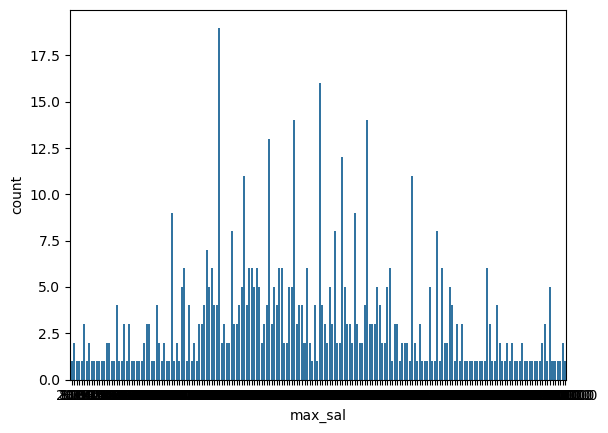

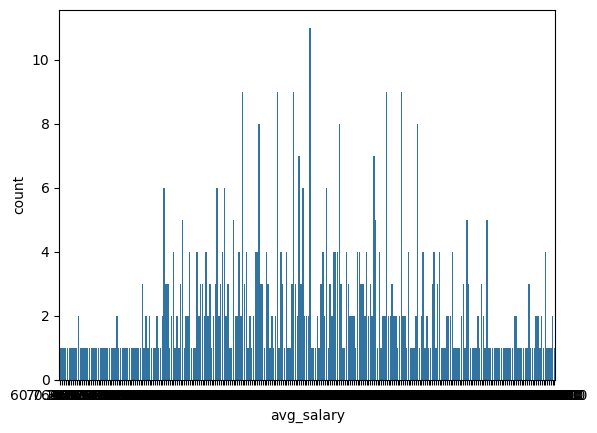

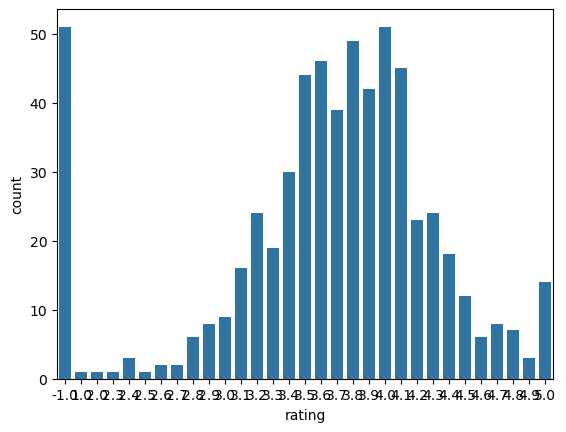

In [82]:
for i in df_cat:
    cat_nums=df_cat[i].value_counts()
    sns.barplot(x=cat_nums.index,y=cat_nums)
    plt.show()

In [83]:
df_cat=df[['min_sal','max_sal','avg_salary','rating']]

In [84]:
print(df_cat)

       min_sal    max_sal  avg_salary  rating
0    100000.00  120000.00  110000.000     4.6
1     90000.00  141000.00  115500.000     3.5
2     68000.00  113000.00   90500.000     3.7
3    108000.00  160000.00  134000.000     4.3
4    101000.00  148000.00  124500.000     4.0
5       160.00     180.00      85.000    -1.0
6     65000.00   75000.00   70000.000     4.3
7    110000.00  135000.00  122500.000    -1.0
8     94000.00  103000.00   98500.000     3.5
9     99000.00  151000.00  125000.000    -1.0
10   105000.00  128000.00  116500.000     4.3
11   100000.00  115000.00  107500.000     3.0
12   124000.00  131000.00  127500.000     3.8
13    78000.00  116000.00   97000.000     3.8
14   150000.00  180000.00  165000.000     4.1
15   142000.00  224000.00  183000.000     4.5
16    85000.00  135000.00  110000.000     4.8
17    99000.00  153000.00  126000.000     3.5
18   123000.00  197000.00  160000.000     3.5
19    96000.00  136000.00  116000.000     2.7
20    83000.00  144000.00  113500.

In [85]:
pd.pivot_table(df,index='job_simp',values='avg_salary')

,avg_salary
job_simp,
analyst,77458.891111
data engineer,154000.000000
data scientist,132336.386748
manager,130000.000000
mle,167472.187500
na,129333.796957
research position,201004.666667


In [86]:
pd.pivot_table(df,index=['job_simp','job_seniority'],values='avg_salary')

avg_salary
job_simp          job_seniority               
analyst           na              91250.000000
                  senior          66426.004000
data engineer     na             154000.000000
data scientist    jr              48523.115000
                  na             127769.515623
                  senior         146772.392660
manager           na             130000.000000
mle               na             167472.187500
na                na             124877.754211
                  senior         150500.000000
research position na             201004.666667

In [87]:
pd.pivot_table(df,index=df.location,values='avg_salary').sort_values('avg_salary',ascending=False)[0:20]

,avg_salary
location,
"Redwood City, CA",249750.000000
"Cupertino, CA",223600.000000
"San Francisco, CA",211344.827586
"Menlo Park, CA",206800.000000
"Hoboken, NJ",198000.000000
"Nashville, TN",195500.000000
"Renton, WA",193500.000000
"Mountain View, CA",192666.666667
"Seattle, WA",184055.555556


In [41]:
pd.pivot_table(df,index=df.state,values='avg_salary').sort_values('avg_salary',ascending=False)

,avg_salary
state,
CA,168918.250438
WA,161875.000000
IA,147500.000000
NY,143642.857143
Remote,141104.892135
HI,140000.000000
TN,136833.333333
IN,135400.000000
SC,132250.000000


In [89]:
pd.options.display.max_rows

In [90]:
pd.set_option('display.max_rows',None)

In [91]:
pd.pivot_table(df,index=[df.state,'job_seniority'],values='avg_salary',aggfunc='count').sort_values('avg_salary',ascending=False)

,,avg_salary
state,job_seniority,
CA,na,96
Remote,na,63
CA,senior,41
Remote,senior,33
NY,na,31
VA,na,30
TX,na,28
IL,na,18
WA,na,17


In [92]:
df.columns

Index(['title', 'company', 'location', 'salary', 'rating', 'hourly', 'min_sal',
       'max_sal', 'avg_salary', 'city', 'state', 'job_simp', 'job_seniority'],
      dtype='object')

In [93]:
df_pivot=df[['rating','hourly','company','avg_salary']]

In [94]:
for i in df_pivot:
    print(i)
    print(pd.pivot_table(df_pivot,index=i,values='avg_salary').sort_values('avg_salary',ascending=False))

rating
           avg_salary
rating               
 4.5    246458.333333
 3.2    162062.500000
 4.2    156310.979130
 2.0    155000.000000
 4.4    153142.083333
 2.8    150083.333333
 2.3    146500.000000
 3.7    143269.230769
 4.0    141188.764706
 4.1    140746.636889
 4.3    138895.833333
 3.9    136682.090238
 4.7    134687.500000
 3.8    134126.524694
 3.4    131302.833333
 2.9    130250.000000
 3.5    130137.193182
 3.3    128578.947368
 1.0    125500.000000
 3.0    125000.000000
 3.6    122268.259348
 5.0    118397.857143
 2.6    109000.000000
 2.5    105000.000000
 3.1    103943.134375
 4.8    103725.785714
 4.9    102500.000000
 2.7     99500.000000
-1.0     87380.914608
 4.6     84512.905000
 2.4     59024.166667
hourly
           avg_salary
hourly               
0       141847.173145
1           65.688077
company
                                                     avg_salary
company                                                        
Netflix                             

ValueError: Grouper for 'avg_salary' not 1-dimensional

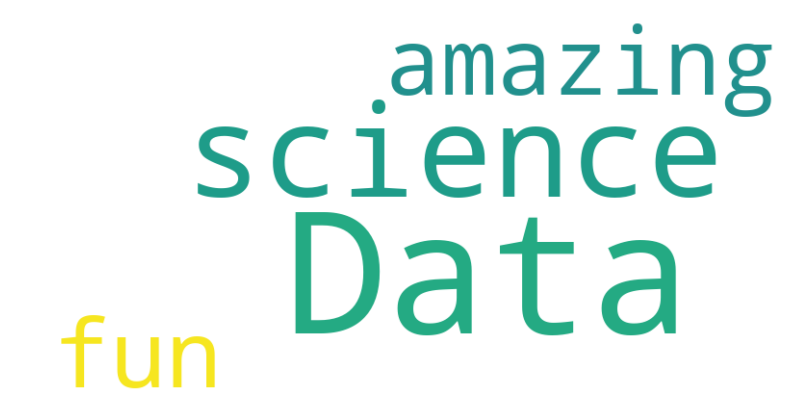

In [95]:
!pip install wordcloud
from wordcloud import WordCloud

text = "Data science is amazing. Data, data, data. Science is fun."

# Generate a word cloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # no axis
plt.show()


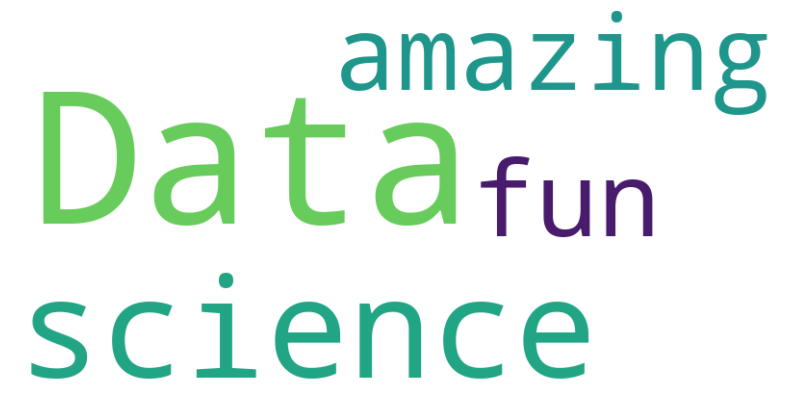

In [96]:
from wordcloud import WordCloud

text = "Data science is amazing. Data, data, data. Science is fun."

# Generate a word cloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # no axis
plt.show()


In [50]:
df.columns

Index(['title', 'company', 'location', 'salary', 'rating', 'hourly', 'min_sal',
       'max_sal', 'avg_salary', 'city', 'state', 'job_simp', 'job_seniority'],
      dtype='object')

In [ ]:
df.to_csv('EDA_Data')